# 05b — Model Training: CNN-LSTM on Hand-Crafted Sequence Features

| Field | Detail |
|---|---|
| **Notebook** | `05b_model_cnn_lstm.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 5 of 7 (Model Training, candidate 2 of 4) |
| **Owner(s)** | *Thrithwaka Preethi* |
| **Created** | *28/08/2026* |
| **Last updated** | *28/08/2026* |
| **Upstream dependency** | `04a_feature_extraction_handcrafted.ipynb` (Feature Set A: MFCC + pitch + energy sequence, and class weights) |
| **Downstream dependency** | `06_model_selection.ipynb` |
| **Runs on** | Local machine, or **Google Colab** with the project folder mounted via Google Drive (see Section 0) |
| **Research proposal reference** | Section 5.1 (*"A CNN-LSTM model will be trained to classify speech into six emotion categories"*) — this is the proposal's **primary** architecture |

## Purpose

This is the proposal's primary voice-emotion architecture, and the second of four independently-trained H1 candidate models (see `docs/research_proposal_mapping.md`). It combines a small stack of **1D convolutional layers** — which learn local patterns across the 42 acoustic features (40 MFCC coefficients + pitch + energy) within each audio frame — with a **bidirectional LSTM**, which learns how those local patterns evolve across the frame sequence. This is the specific reason `04a_feature_extraction_handcrafted.ipynb` extracted Feature Set A as a genuine `(T, 42)` time-series rather than a single averaged vector: an LSTM has nothing to learn from if the time axis has already been collapsed away before it ever sees the data.

### Why both a CNN and an LSTM, and in that order

The CNN component first summarizes each frame's 42 raw features into a smaller number of higher-level, locally-informed feature channels — similar in spirit to how a CNN extracts edges and textures from an image before a later layer reasons about their arrangement. The LSTM then models how those higher-level representations change moment to moment across the utterance, which is what should capture the *shape* of an emotional expression over time (e.g. anger's rising energy, or the flat trajectory typical of a neutral or sad reading) rather than treating each frame as independent.

## Objectives

1. Load and validate Feature Set A and class weights from `04a`.
2. Fit a feature scaler on the **training split only**, and apply it consistently to validation and test — saving the fitted scaler alongside the model, since any future inference on new audio must use this exact same scaling.
3. Define a CNN-LSTM architecture matching the proposal's Section 5.1 description, with an explicit rationale for every design choice.
4. Train with class-weighted loss, a learning-rate scheduler, and early stopping.
5. Evaluate on the held-out test split using Accuracy, Precision, Recall, and F1-score (Section 5.5's metrics).
6. Save the trained model, scaler, training curves, confusion matrix, and full run metadata.
7. Append this run's results to the shared cross-model experiment log.
8. Leave a structured handoff note, including the outstanding integration task with `src/emotion/voice_emotion.py` flagged back in `04a`.

## 0. Environment Setup

### 0.1 Google Colab / Google Drive Setup

Auto-detects Colab and mounts Google Drive if needed, falling back to local path resolution otherwise — identical pattern to `05a_model_cnn_raw.ipynb`, so this single notebook file works in both environments. If your Drive folder path differs from `MyDrive/emotion-ai-companion-research`, edit the `PROJECT_ROOT` line below before running.

**Recommended Colab runtime:** `Runtime` \u2192 `Change runtime type` \u2192 **T4 GPU**.

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-ai-companion-research")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"{PROJECT_ROOT} not found. Check that this path matches your Google Drive folder "
            "exactly (case-sensitive), and that the cell above finished mounting successfully."
        )

    os.chdir(PROJECT_ROOT)
    print(f"\u2705 Running on Google Colab. Project root set to: {PROJECT_ROOT}")

else:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    print(f"Running locally. Project root resolved to: {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive
✅ Running on Google Colab. Project root set to: /content/drive/MyDrive/emotion-ai-companion-research


In [2]:
if IN_COLAB:
    print("Installing project-specific dependencies not pre-installed on Colab...")
    !pip install -q pydantic-settings==2.4.0
    print("Done.")
else:
    print("Running locally — skipping Colab-specific dependency installation.")

Installing project-specific dependencies not pre-installed on Colab...
Done.


In [3]:
import json
import time
import logging
import subprocess
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
)

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid")

In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("\u26a0\ufe0f  No GPU detected. If on Colab, go to Runtime \u2192 Change runtime type \u2192 "
          "T4 GPU, then re-run this notebook from the top.")

Using device: cuda


In [5]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "05b_model_cnn_lstm.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("model_cnn_lstm")
logger.info("Environment: %s", "Google Colab" if IN_COLAB else "local")

## 1. Load & Validate Upstream Outputs

Loads Feature Set A specifically (`X_set_a`) — the `(T, 42)` sequence array — not Feature Set B, which belongs to `05c`'s ensemble model.

In [6]:
handcrafted_npz_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features.npz"
handcrafted_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features_metadata.json"

for path in (handcrafted_npz_path, handcrafted_metadata_path):
    if not path.exists():
        raise FileNotFoundError(f"{path} not found. Run 04a_feature_extraction_handcrafted.ipynb first.")

with open(handcrafted_metadata_path) as f:
    handcrafted_metadata = json.load(f)

assert handcrafted_metadata["total_files_failed"] == 0, "04a reported extraction failures — resolve before training."

label_to_idx = {k: int(v) for k, v in handcrafted_metadata["label_to_idx"].items()}
idx_to_label = {int(k): v for k, v in handcrafted_metadata["idx_to_label"].items()}
NUM_CLASSES = len(label_to_idx)

logger.info("Upstream validated. %d classes.", NUM_CLASSES)
print(f"\u2705 Upstream validated. {NUM_CLASSES} classes: {list(label_to_idx.keys())}")

✅ Upstream validated. 6 classes: ['happy', 'sad', 'angry', 'fear', 'neutral', 'surprise']


In [7]:
data = np.load(handcrafted_npz_path, allow_pickle=True)
X_set_a, y, split = data["X_set_a"], data["y"], data["split"]

print(f"X_set_a shape: {X_set_a.shape}  (N, T, features_per_frame)")
print(f"Split sizes: {pd.Series(split).value_counts().to_dict()}")

T, FEATURES_PER_FRAME = X_set_a.shape[1], X_set_a.shape[2]
assert [T, FEATURES_PER_FRAME] == handcrafted_metadata["feature_set_a"]["shape"]
print(f"Sequence length T={T}, features per frame={FEATURES_PER_FRAME} (40 MFCC + pitch + energy)")

X_set_a shape: (4068, 79, 42)  (N, T, features_per_frame)
Split sizes: {'train': 3254, 'val': 407, 'test': 407}
Sequence length T=79, features per frame=42 (40 MFCC + pitch + energy)


## 2. Feature Scaling — Fit on Training Split Only

`04a` deliberately saved these features unscaled, leaving normalization to each model notebook — this is where that responsibility is exercised for the CNN-LSTM candidate. A `StandardScaler` is fit on the **training split only** (reshaped to treat every frame across every training clip as one sample, since we want to normalize each of the 42 feature channels independently, not each clip) and then applied identically to validation and test. The fitted scaler is saved alongside the model, since any future inference on new audio must apply this exact same transformation, not a freshly-fit one.

In [8]:
train_mask, val_mask, test_mask = split == "train", split == "val", split == "test"

# Reshape (N, T, 42) -> (N*T, 42) so StandardScaler fits per-feature statistics across all frames.
X_train_flat = X_set_a[train_mask].reshape(-1, FEATURES_PER_FRAME)

scaler = StandardScaler()
scaler.fit(X_train_flat)


def apply_scaler(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    n, t, f = X.shape
    X_scaled = scaler.transform(X.reshape(-1, f))
    return X_scaled.reshape(n, t, f).astype(np.float32)


X_train = apply_scaler(X_set_a[train_mask], scaler)
X_val = apply_scaler(X_set_a[val_mask], scaler)
X_test = apply_scaler(X_set_a[test_mask], scaler)
y_train, y_val, y_test = y[train_mask], y[val_mask], y[test_mask]

print(f"Scaler fit on {len(X_train_flat)} training frames.")
print(f"Post-scaling train mean (should be \u2248 0): {X_train.mean():.4f}, std (should be \u2248 1): {X_train.std():.4f}")

Scaler fit on 257066 training frames.
Post-scaling train mean (should be ≈ 0): 0.0000, std (should be ≈ 1): 1.0000


## 3. Configuration

In [9]:
BATCH_SIZE = 32
MAX_EPOCHS = 100
LEARNING_RATE = 1e-3
LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_FACTOR = 0.5
EARLY_STOPPING_PATIENCE = 5
CNN_DROPOUT = 0.25
LSTM_HIDDEN_SIZE = 128
LSTM_NUM_LAYERS = 1
CLASSIFIER_DROPOUT = 0.3
WEIGHT_DECAY = 1e-4

MODEL_DIR = PROJECT_ROOT / "models" / "h1"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "cnn_lstm.pt"
SCALER_PATH = MODEL_DIR / "cnn_lstm_scaler.pkl"
MODEL_METADATA_PATH = MODEL_DIR / "cnn_lstm_metadata.json"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_LOG_PATH = PROJECT_ROOT / "reports" / "experiment_log.csv"

joblib.dump(scaler, SCALER_PATH)
logger.info("Saved fitted scaler to %s", SCALER_PATH)
print(f"Scaler saved: {SCALER_PATH}")

Scaler saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/cnn_lstm_scaler.pkl


## 4. Dataset and DataLoaders

In [10]:
class SequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()  # (N, T, 42)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = SequenceDataset(X_train, y_train)
val_dataset = SequenceDataset(X_val, y_val)
test_dataset = SequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3254 | Val: 407 | Test: 407


In [11]:
class_weights_by_label = handcrafted_metadata["class_weights"]
class_weights_tensor = torch.tensor(
    [class_weights_by_label[idx_to_label[i]] for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(DEVICE)

print("Class weights (reused from 04a) in label-index order:")
for i in range(NUM_CLASSES):
    print(f"  {i} ({idx_to_label[i]}): {class_weights_tensor[i].item():.4f}")

Class weights (reused from 04a) in label-index order:
  0 (happy): 1.0409
  1 (sad): 1.0390
  2 (angry): 1.0390
  3 (fear): 1.0390
  4 (neutral): 0.8395
  5 (surprise): 1.0409


## 5. Model Definition

**CNN stage:** two Conv1D blocks operate over the time axis, treating the 42 acoustic features as input channels — `Conv1d(42 \u2192 64)` then `Conv1d(64 \u2192 128)`, each with batch normalization, ReLU, and dropout. A single `MaxPool1d(2)` after the second block modestly reduces the sequence length before the LSTM, cutting compute without discarding meaningful temporal resolution.

**LSTM stage:** a bidirectional LSTM processes the CNN's output sequence, so the model can use both past and future context within each utterance when interpreting any given moment — appropriate here since we have the entire utterance available at once (this is not a real-time/streaming use case).

**Pooling and classification head:** rather than using only the LSTM's final hidden state (which can lose information from earlier in a longer utterance), this model mean-pools the LSTM's output across the full time axis — the same design philosophy as `05a`'s global average pooling, applied here to the time dimension instead of a raw waveform.

In [12]:
class CNNLSTM(nn.Module):
    def __init__(
        self,
        num_classes: int,
        input_features: int = FEATURES_PER_FRAME,
        lstm_hidden_size: int = LSTM_HIDDEN_SIZE,
        lstm_num_layers: int = LSTM_NUM_LAYERS,
        cnn_dropout: float = CNN_DROPOUT,
        classifier_dropout: float = CLASSIFIER_DROPOUT,
    ):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(cnn_dropout),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(cnn_dropout),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            bidirectional=True,
        )

        lstm_output_size = lstm_hidden_size * 2  # bidirectional
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (batch, T, 42) -> Conv1d expects (batch, channels, T)
        x = x.permute(0, 2, 1)          # (batch, 42, T)
        x = self.cnn(x)                 # (batch, 128, T')
        x = x.permute(0, 2, 1)          # (batch, T', 128) — back to sequence-first for the LSTM

        lstm_out, _ = self.lstm(x)      # (batch, T', 256)
        pooled = lstm_out.mean(dim=1)   # mean-pool across time -> (batch, 256)

        return self.classifier(pooled)


model = CNNLSTM(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
logger.info("Model instantiated. Total params: %d", total_params)

Total parameters: 331,078


## 6. Training Loop

Same training discipline as `05a`: class-weighted cross-entropy, `ReduceLROnPlateau`, early stopping on validation loss, and the best checkpoint (by validation loss) is what gets saved and evaluated.

In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
)


def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

In [14]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

training_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    logger.info(
        "Epoch %3d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f | lr=%.2e",
        epoch, train_loss, train_acc, val_loss, val_acc, current_lr,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        logger.info("Early stopping triggered at epoch %d (best epoch: %d).", epoch, best_epoch)
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best val_loss: {best_val_loss:.4f})")
        break

training_duration_seconds = time.time() - training_start
print(f"\nTraining complete in {training_duration_seconds:.1f}s. Best epoch: {best_epoch} (val_loss={best_val_loss:.4f}).")

Early stopping at epoch 23 (best epoch: 18, best val_loss: 0.3237)

Training complete in 14.1s. Best epoch: 18 (val_loss=0.3237).


## 7. Training Curves

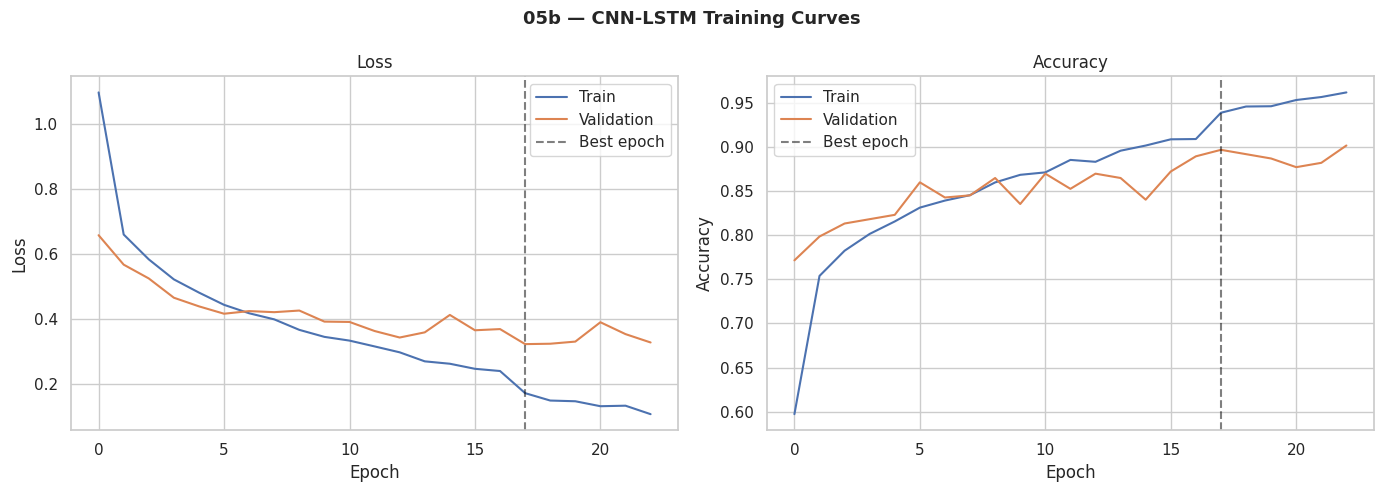

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

fig.suptitle("05b — CNN-LSTM Training Curves", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05b_training_curves.png")
plt.show()

## 8. Test Set Evaluation

In [16]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print(f"Test Accuracy:            {test_accuracy:.4f}")
print(f"Test Precision (macro):   {precision_macro:.4f}")
print(f"Test Recall (macro):      {recall_macro:.4f}")
print(f"Test F1 (macro):          {f1_macro:.4f}")
print(f"Test F1 (weighted):       {f1_weighted:.4f}")
print("\nPer-class report:\n")
print(classification_report(
    all_labels, all_preds, target_names=[idx_to_label[i] for i in range(NUM_CLASSES)], zero_division=0
))

Test Accuracy:            0.8894
Test Precision (macro):   0.8913
Test Recall (macro):      0.8870
Test F1 (macro):          0.8883
Test F1 (weighted):       0.8891

Per-class report:

              precision    recall  f1-score   support

       happy       0.84      0.86      0.85        66
         sad       0.92      0.88      0.90        65
       angry       0.90      0.94      0.92        65
        fear       0.90      0.85      0.87        65
     neutral       0.88      0.95      0.91        81
    surprise       0.92      0.85      0.88        65

    accuracy                           0.89       407
   macro avg       0.89      0.89      0.89       407
weighted avg       0.89      0.89      0.89       407



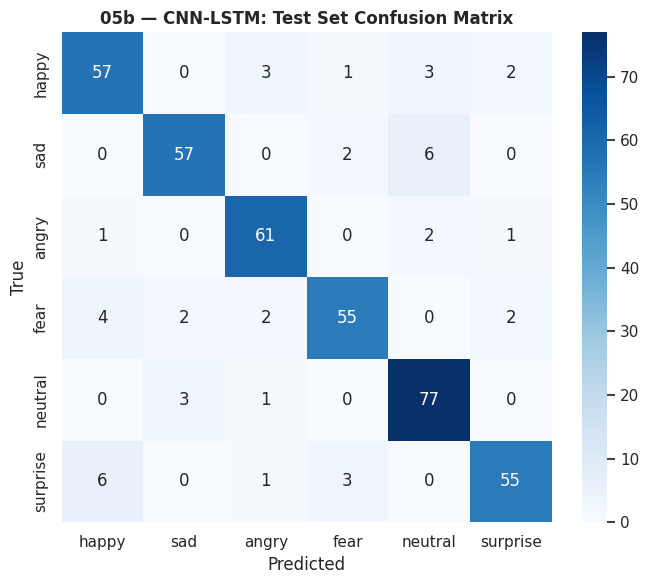

In [17]:
cm = confusion_matrix(all_labels, all_preds)
labels_ordered = [idx_to_label[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax)
ax.set_title("05b — CNN-LSTM: Test Set Confusion Matrix", fontsize=12, weight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05b_confusion_matrix.png")
plt.show()

## 9. Save Model Metadata

In [18]:
def get_git_commit_hash() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"


model_metadata = {
    "model_name": "cnn_lstm",
    "architecture": "CNN-LSTM (2-block Conv1D over 42 acoustic features -> Bi-LSTM -> mean pooling -> dense classifier)",
    "research_proposal_reference": "Section 5.1 — primary voice-emotion architecture",
    "input_shape": [int(T), int(FEATURES_PER_FRAME)],
    "num_classes": NUM_CLASSES,
    "label_to_idx": label_to_idx,
    "scaler_path": str(SCALER_PATH.relative_to(PROJECT_ROOT)),
    "scaler_note": "StandardScaler fit on the training split only. MUST be applied to any new input before inference — see SCALER_PATH.",
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "cnn_dropout": CNN_DROPOUT,
        "classifier_dropout": CLASSIFIER_DROPOUT,
        "lstm_hidden_size": LSTM_HIDDEN_SIZE,
        "lstm_num_layers": LSTM_NUM_LAYERS,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
    },
    "training": {
        "best_epoch": best_epoch,
        "epochs_run": len(history["train_loss"]),
        "best_val_loss": float(best_val_loss),
        "training_duration_seconds": round(training_duration_seconds, 1),
        "device": str(DEVICE),
        "environment": "Google Colab" if IN_COLAB else "local",
    },
    "test_metrics": {
        "accuracy": float(test_accuracy),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    },
    "total_parameters": int(total_params),
    "git_commit": get_git_commit_hash(),
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
}

with open(MODEL_METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=2)

logger.info("Saved model metadata to %s", MODEL_METADATA_PATH)
print(f"Saved: {MODEL_PATH}")
print(f"Saved: {SCALER_PATH}")
print(f"Saved: {MODEL_METADATA_PATH}")

Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/cnn_lstm.pt
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/cnn_lstm_scaler.pkl
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/cnn_lstm_metadata.json


## 10. Append to Shared Experiment Log

In [19]:
experiment_row = {
    "notebook": "05b_model_cnn_lstm",
    "model_name": "cnn_lstm",
    "timestamp_utc": model_metadata["trained_at_utc"],
    "git_commit": model_metadata["git_commit"],
    "environment": model_metadata["training"]["environment"],
    "test_accuracy": test_accuracy,
    "test_precision_macro": precision_macro,
    "test_recall_macro": recall_macro,
    "test_f1_macro": f1_macro,
    "test_f1_weighted": f1_weighted,
    "best_epoch": best_epoch,
    "epochs_run": len(history["train_loss"]),
    "total_parameters": total_params,
    "training_duration_seconds": round(training_duration_seconds, 1),
    "model_metadata_path": str(MODEL_METADATA_PATH.relative_to(PROJECT_ROOT)),
}

experiment_log_df = (
    pd.read_csv(EXPERIMENT_LOG_PATH) if EXPERIMENT_LOG_PATH.exists() else pd.DataFrame()
)
experiment_log_df = pd.concat([experiment_log_df, pd.DataFrame([experiment_row])], ignore_index=True)
experiment_log_df.to_csv(EXPERIMENT_LOG_PATH, index=False)

logger.info("Appended results to shared experiment log: %s", EXPERIMENT_LOG_PATH)
print(f"Appended to: {EXPERIMENT_LOG_PATH}")
experiment_log_df.tail(3)

Appended to: /content/drive/MyDrive/emotion-ai-companion-research/reports/experiment_log.csv


,notebook,model_name,timestamp_utc,git_commit,environment,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,best_epoch,epochs_run,total_parameters,training_duration_seconds,model_metadata_path
0,05a_model_cnn_raw,cnn_raw,2026-08-29T08:13:48.614251+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.803440,0.824199,0.800714,0.801215,0.804571,11,16,716422,227.7,models/h1/cnn_raw_metadata.json
1,05b_model_cnn_lstm,cnn_lstm,2026-08-29T08:31:10.368142+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.889435,0.891326,0.886991,0.888323,0.889131,18,23,331078,14.1,models/h1/cnn_lstm_metadata.json


## 11. Final Sanity Check — Reload and Verify

In [20]:
reload_model = CNNLSTM(num_classes=NUM_CLASSES).to(DEVICE)
reload_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
reload_model.eval()

reload_scaler = joblib.load(SCALER_PATH)

sample_X, sample_y = next(iter(test_loader))
with torch.no_grad():
    reload_logits = reload_model(sample_X.to(DEVICE))
    reload_preds = reload_logits.argmax(dim=1).cpu()

assert reload_logits.shape == (sample_X.shape[0], NUM_CLASSES), "Unexpected output shape from reloaded model!"
print("\u2705 Reloaded model produces correctly-shaped output.")
print("\u2705 Reloaded scaler loads without error.")
print(f"Sample predictions: {[idx_to_label[p.item()] for p in reload_preds[:5]]}")
print(f"Sample true labels: {[idx_to_label[l.item()] for l in sample_y[:5]]}")

✅ Reloaded model produces correctly-shaped output.
✅ Reloaded scaler loads without error.
Sample predictions: ['angry', 'sad', 'surprise', 'neutral', 'surprise']
Sample true labels: ['angry', 'sad', 'surprise', 'neutral', 'surprise']


---

## Summary Note — Handoff
### What was done in this notebook

1. Detected the runtime environment (Colab vs. local) and set up `PROJECT_ROOT` accordingly.
2. Loaded Feature Set A (MFCC + pitch + energy sequences) and class weights from `04a`.
3. Fit a `StandardScaler` on the training split only, applied it to all three splits, and saved the fitted scaler alongside the model.
4. Defined and trained a CNN-LSTM (2-block Conv1D \u2192 Bi-LSTM \u2192 mean pooling \u2192 dense classifier) matching the proposal's Section 5.1 primary architecture.
5. Evaluated the best checkpoint on the held-out test split: Accuracy, Precision, Recall, F1 (macro and weighted), full classification report, and confusion matrix.
6. Saved the trained model, scaler, training curves, confusion matrix, and full run metadata.
7. Appended this run's results to the shared `reports/experiment_log.csv`.
8. Reloaded the model and scaler independently and confirmed both work correctly.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| Trained model weights | `models/h1/cnn_lstm.pt` | `06_model_selection.ipynb` |
| Fitted feature scaler | `models/h1/cnn_lstm_scaler.pkl` | Any future inference on new audio — **must** be applied before feeding features to this model |
| Model metadata | `models/h1/cnn_lstm_metadata.json` | `06_model_selection.ipynb`; thesis results section |
| Training curves / confusion matrix figures | `reports/figures/h1_models/05b_*.png` | Thesis results/appendix |
| Shared experiment log (one row appended) | `reports/experiment_log.csv` | `06_model_selection.ipynb` |
| Run log | `reports/logs/05b_model_cnn_lstm.log` | Debugging |

### What needs to be done next

- **`05c_model_ensemble.ipynb`**, **`05d_model_wav2vec2.ipynb`** — independent of this notebook; run in any order.
- Once all four H1 candidates are trained, **`06_model_selection.ipynb`** compares them via `reports/experiment_log.csv`.
- **If this model is selected as the H1 winner:** `src/emotion/voice_emotion.py`'s `CNNLSTMVoiceEmotionClassifier` currently mean-pools features into a single vector for live inference (flagged as an outstanding task back in `04a`). It will need updating to (a) extract the full `(T, 42)` sequence rather than a mean-pooled vector, and (b) apply `models/h1/cnn_lstm_scaler.pkl` before passing features to the model, matching exactly what this notebook did during training. This is a deployment task, not a modeling task — but it cannot be skipped if this model goes into the live app.

**Before running `06_model_selection.ipynb`, confirm:**
- This notebook's row appears correctly in `reports/experiment_log.csv`.
- `models/h1/cnn_lstm.pt`, `cnn_lstm_scaler.pkl`, and `cnn_lstm_metadata.json` all exist.
- Section 11's reload sanity check printed \u2705 for both the model and the scaler.

### Resources needed for the next step

| Resource | Needed for | Notes |
|---|---|---|
| `reports/experiment_log.csv` | Cross-model comparison table | Shared across all `05a`\u2013`05e` notebooks |
| `models/h1/cnn_lstm*.{pt,pkl,json}` | Loading this model (and its required scaler) for further analysis | The `.pkl` scaler is not optional — using this model without it will produce meaningless predictions |

### Known issues / things to watch for
None

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakya*
- **Date:** *28/08/2026*
- **Environment:** *Colab*
- **Best epoch / epochs run:** *18*
- **Test accuracy / F1 (macro):** *0.8883*